Step 1: Read and draw a graph
- take a given file in edge list format, e.g. Les Misérables network, Jazz network
- load the file into your own program (build data structures for that)
- create and draw a layout (node-link diagram) for the loaded graph. Feel free to imagine any kind of layout you want, e.g. some user-defined functions for the x,y coordinates.
- explain what's the computational complexity of your layout algorithm
- comment on the pro's / con's of your resulting layout
- (bonus) Give yourself 10 minutes to think of a simple algorithm for graph drawing that theoretically should produce results better than your previous attempt. Implement this algorithm, show your results, compare to the drawings produced by the previous algorithm, and analyze the algorithm’s running time.

## Solution:

Importing libraries:

In [2]:
import pandas as pd
import pydot
import matplotlib
import graphviz

Loading the graph data (dot file) using pydot:

In [3]:
# this software has to do the following:
# 0. names of the dot files that contain the data:
data_name_1 = "../Dataset/Step1/JazzNetwork.dot"
data_name_2 = "../Dataset/Step1/LesMiserables.dot"

# 1. read in the data from the dot file "data.dot" using pydot library:
G = pydot.graph_from_dot_file(data_name_1)
graph = G[0]

List of nodes:

In [4]:
nodes = graph.get_nodes()
node_names = [node.get_name() for node in nodes]
print(node_names)

['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '3', '4', '5', '6', '7', '8', '9', '120', '121', '122', '123', '124', '125', '67', '130', '145', '146', '147', '148', '149', '150', '157', '159', '160', '101', '112', '128', '133', '137', '152', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '177', '178', '179', '153', '155', '100', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '116', '117', '118', '119', '127', '138', '139', '140', '154', '191', '26', '27', '28', '48', '54', '55', '74', '75', '76', '80', '81', '83', '84', '85', '86', '87', '89', '90', '92', '93', '95', '96', '97', '98', '91', '94', '134', '192', '114', '158', '88', '187', '188', '189', '56', '135', '176', '193', '126', '131', '132', '31', '25', '115', '144', '62', '113', '35', '70', '29', '30', '32', '33', '143', '78', '79', '141', '142', '161', '180', '183', '184', '34', '36', '37', '42', '50', '51', '52', '53', '5

List of edges:

In [5]:
edges = graph.get_edges()
edge_list = [(edge.get_source(), edge.get_destination()) for edge in edges]
print(edge_list)

[('1', '10'), ('1', '11'), ('1', '12'), ('1', '13'), ('1', '14'), ('1', '15'), ('1', '16'), ('1', '17'), ('1', '18'), ('1', '19'), ('1', '2'), ('1', '20'), ('1', '21'), ('1', '22'), ('1', '23'), ('1', '24'), ('1', '3'), ('1', '4'), ('1', '5'), ('1', '6'), ('1', '7'), ('1', '8'), ('1', '9'), ('10', '3'), ('10', '5'), ('10', '6'), ('10', '7'), ('10', '109'), ('10', '111'), ('10', '112'), ('10', '114'), ('10', '119'), ('10', '12'), ('10', '125'), ('10', '13'), ('10', '14'), ('10', '145'), ('10', '146'), ('10', '147'), ('10', '149'), ('10', '15'), ('10', '153'), ('10', '155'), ('10', '158'), ('10', '159'), ('10', '160'), ('10', '164'), ('10', '165'), ('10', '17'), ('10', '18'), ('10', '19'), ('10', '20'), ('10', '28'), ('10', '54'), ('10', '67'), ('10', '74'), ('10', '75'), ('10', '76'), ('10', '80'), ('10', '83'), ('10', '85'), ('10', '86'), ('10', '88'), ('10', '93'), ('11', '2'), ('11', '4'), ('11', '6'), ('11', '7'), ('11', '9'), ('11', '101'), ('11', '102'), ('11', '103'), ('11', '106

Using networkx, plotting the graph:

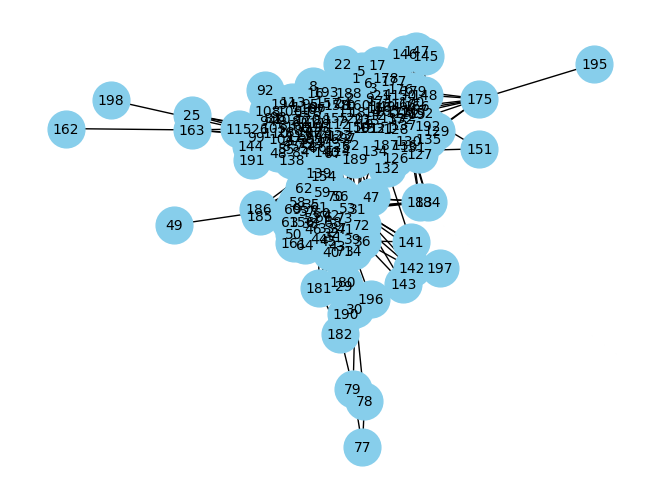

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

from networkx.drawing.nx_pydot import from_pydot

G_nx = from_pydot(graph)

pos = nx.spring_layout(G_nx)
nx.draw(G_nx, pos, with_labels=True, node_size=700, node_color="skyblue", font_size=10, font_color="black")
plt.show()


Alternatively, we can draw the graph using matplotlib

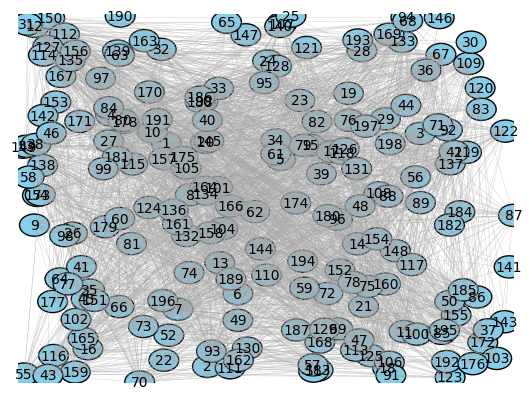

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import numpy as np
import pydot

# Load the graph from a dot file
data_name_1 = "../Dataset/Step1/JazzNetwork.dot"
graphs = pydot.graph_from_dot_file(data_name_1)
graph = graphs[0]

def get_unique_random_position(existing_positions, max_attempts=100):
    """Generate a unique random position that does not overlap significantly with existing ones."""
    for _ in range(max_attempts):
        pos = np.random.rand(2)
        if all(np.linalg.norm(pos - existing) > 0.05 for existing in existing_positions.values()):
            return pos
    return np.random.rand(2)  # Fallback if no unique position is found

# Get the list of nodes and edges
nodes = graph.get_nodes()
edges = graph.get_edges()

# Create a dictionary to store node positions
node_positions = {}

# Initialize the plot
fig, ax = plt.subplots()

# Generate a random position and plot a circle for each node
for node in nodes:
    pos = np.random.rand(2)
    node_positions[node.get_name()] = pos
    ax.add_patch(Circle(pos, radius=0.03, edgecolor='black', facecolor='skyblue'))
    ax.text(pos[0], pos[1], node.get_name(), fontsize=10, ha='center', va='center')

# Draw lines to connect the circles based on edges
for edge in edges:
    source_pos = node_positions[edge.get_source()]
    destination_pos = node_positions[edge.get_destination()]
    ax.add_patch(ConnectionPatch(
        source_pos, destination_pos, 'data', 'data', color='#A9A9A9', # dark grey lines
        linestyle=':', linewidth=0.3  # Make lines thinner and dotted
    ))


# Set plot limits
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Hide the axes
ax.axis('off')

plt.show()


There are a bunch of problems with this layout:
- randomly positioned nodes create a mess. They sometimes overlapp as well and some of them are on the border or edges of the canvas;
- too many edges intersections. However, no banding edges;
- the graph might be to sparse. We may be able to use less space and lower the stress (total width of the graph);
- Furthermore, we may have crossings on bigger angles and consider using different shapes and/or sizes (es: nodes with more connections should be bigger (central), than not connected nodes or nodes with only one connection)

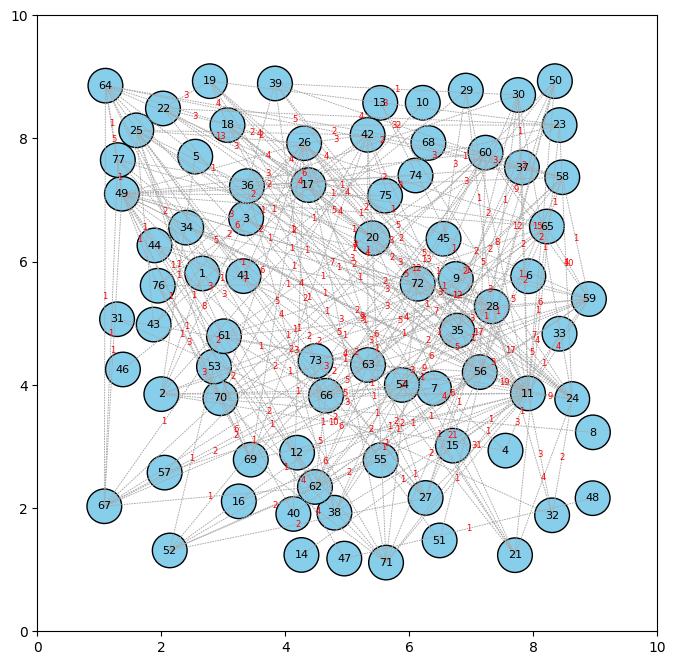

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import numpy as np
import pydot

def get_unique_random_position(existing_positions, max_attempts=100):
    """Generate a unique random position that does not overlap significantly with existing ones."""
    for _ in range(max_attempts):
        pos = (0.1 + (0.9 - 0.1) * np.random.rand(2))*10
        if all(np.linalg.norm(pos - existing) > 0.5 for existing in existing_positions.values()):
            return pos
    return np.random.rand(2)  # Fallback if no unique position is found

# Load the graph from a dot file
data_name_1 = "../Dataset/Step1/LesMiserables.dot"
graphs = pydot.graph_from_dot_file(data_name_1)
graph = graphs[0]

# Get nodes and edges
nodes = graph.get_nodes()
edges = graph.get_edges()

# Store node positions
node_positions = {}

# Initialize the plot
fig, ax = plt.subplots(figsize=(8, 8))

# Assign unique random positions to nodes
for node in nodes:
    node_name = node.get_name()
    if node_name.isdigit():  # Ensure we ignore special characters
        node_positions[node_name] = get_unique_random_position(node_positions)
        ax.add_patch(Circle(node_positions[node_name], radius=0.28, edgecolor='black', facecolor='skyblue'))
        ax.text(node_positions[node_name][0], node_positions[node_name][1], node_name, fontsize=8, ha='center', va='center')

# Draw edges with weights
for edge in edges:
    source, target = edge.get_source(), edge.get_destination()
    if source.isdigit() and target.isdigit():
        source_pos = node_positions[source]
        target_pos = node_positions[target]
        weight = edge.get_attributes().get("weight", "1")  # Get weight, default to 1
        ax.add_patch(ConnectionPatch(
            source_pos, target_pos, 'data', 'data', color='#A9A9A9', linestyle=':', linewidth=0.6
        ))
        mid_pos = (source_pos + target_pos) / 2  # Midpoint for weight label
        ax.text(mid_pos[0], mid_pos[1], weight, fontsize=6, color='red', ha='center', va='center')

# Set plot limits
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('on')

plt.show()

In [51]:
pos = (0.1 + (0.9 - 0.1) * np.random.rand(2))*10
print(pos)

[8.67862907 5.32774831]
